# Chicago Crime Data - Understanding

Step-by-step analysis to understand the dataset, decide which columns to keep or add, and prepare for cleaning and modeling.

In [1]:
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.precision', 2)
pd.set_option('display.max_colwidth', None)

In [2]:
# Load the Chicago crimes dataset
df = pd.read_csv('../../data/raw/crimes.csv')

In [3]:
# Initial glimpse of the data
df.head(10)

,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
0,14135339,JK179351,03/13/2026 12:00:00 AM,075XX S KINGSTON AVE,0760,BURGLARY,BURGLARY FROM MOTOR VEHICLE,STREET,False,False,421,4.00,7.00,43.00,06,1194503.00,1855492.00,2026,03/20/2026 03:43:34 PM,41.76,-87.56,"(41.758395718, -87.562722643)"
1,14135179,JK179134,03/13/2026 12:00:00 AM,050XX N MARINE DR,1310,CRIMINAL DAMAGE,TO PROPERTY,RESIDENCE - GARAGE,False,False,2024,20.00,48.00,3.00,14,1169716.00,1933892.00,2026,03/20/2026 03:43:34 PM,41.97,-87.65,"(41.974104832, -87.651281486)"
2,14138214,JK183002,03/13/2026 12:00:00 AM,075XX S STONY ISLAND AVE,0281,CRIMINAL SEXUAL ASSAULT,NON-AGGRAVATED,HOSPITAL BUILDING / GROUNDS,False,False,411,4.00,8.00,43.00,02,1188234.00,1855158.00,2026,03/20/2026 03:43:34 PM,41.76,-87.59,"(41.757630995, -87.585708249)"
3,14136294,JK180526,03/13/2026 12:00:00 AM,002XX E HURON ST,0281,CRIMINAL SEXUAL ASSAULT,NON-AGGRAVATED,HOSPITAL BUILDING / GROUNDS,False,False,1834,18.00,2.00,8.00,02,1178046.00,1905133.00,2026,03/20/2026 03:43:34 PM,41.90,-87.62,"(41.895003278, -87.62152816)"
4,14138215,JK182922,03/13/2026 12:00:00 AM,066XX W BELDEN AVE,1242,DECEPTIVE PRACTICE,COMPUTER FRAUD,OTHER (SPECIFY),False,False,2512,25.00,29.00,18.00,11,1131571.00,1914340.00,2026,03/20/2026 03:43:34 PM,41.92,-87.79,"(41.921199662, -87.792007111)"
5,14135487,JK179323,03/13/2026 12:00:00 AM,025XX W LEXINGTON ST,0460,BATTERY,SIMPLE,SIDEWALK,False,False,1135,11.00,28.00,28.00,08B,1159585.00,1896617.00,2026,03/20/2026 03:43:34 PM,41.87,-87.69,"(41.872034864, -87.689564973)"
6,14135936,JK179489,03/13/2026 12:00:00 AM,001XX W KINZIE ST,1150,DECEPTIVE PRACTICE,CREDIT CARD FRAUD,OTHER (SPECIFY),False,False,1831,18.00,42.00,8.00,11,1174923.00,1902985.00,2026,03/20/2026 03:43:34 PM,41.89,-87.63,"(41.889179572, -87.633062369)"
7,14136555,JK180890,03/13/2026 12:00:00 AM,016XX W BARRY AVE,0760,BURGLARY,BURGLARY FROM MOTOR VEHICLE,STREET,False,False,1931,19.00,32.00,6.00,06,1164945.00,1920647.00,2026,03/20/2026 03:43:34 PM,41.94,-87.67,"(41.937862854, -87.669203157)"
8,14135230,JK179151,03/13/2026 12:00:00 AM,097XX S COMMERCIAL AVE,2826,OTHER OFFENSE,HARASSMENT BY ELECTRONIC MEANS,RESIDENCE,False,False,431,4.00,10.00,51.00,26,1197829.00,1840909.00,2026,03/20/2026 03:43:34 PM,41.72,-87.55,"(41.718296435, -87.551019241)"
9,14135362,JK179414,03/13/2026 12:00:00 AM,001XX S HALSTED ST,0560,ASSAULT,SIMPLE,SMALL RETAIL STORE,False,False,1232,12.00,34.00,28.00,08A,1171070.00,1899648.00,2026,03/20/2026 03:43:34 PM,41.88,-87.65,"(41.880108035, -87.647309981)"


## 1. Dataset Overview

Understand the basic structure: shape, columns, data types.

In [4]:
print("Dataset shape:", df.shape)
print("\nColumn names and types:")
print(df.dtypes)
print("\nBasic stats:")
df.info()

Dataset shape: (2477115, 22)

Column names and types:
ID                        int64
Case Number                 str
Date                        str
Block                       str
IUCR                        str
Primary Type                str
Description                 str
Location Description        str
Arrest                     bool
Domestic                   bool
Beat                      int64
District                float64
Ward                    float64
Community Area          float64
FBI Code                    str
X Coordinate            float64
Y Coordinate            float64
Year                      int64
Updated On                  str
Latitude                float64
Longitude               float64
Location                    str
dtype: object

Basic stats:
<class 'pandas.DataFrame'>
RangeIndex: 2477115 entries, 0 to 2477114
Data columns (total 22 columns):
 #   Column                Dtype  
---  ------                -----  
 0   ID                    int64  
 1   Ca

## 2. Missing Values Analysis

Identify columns with missing data - critical for deciding column retention and cleaning strategy.

In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)
missing_df

,Missing Count,Missing %
X Coordinate,35605,1.44
Y Coordinate,35605,1.44
Latitude,35605,1.44
Longitude,35605,1.44
Location,35605,1.44
Location Description,13003,0.52
Community Area,203,0.01
Ward,54,0.00
District,1,0.00


## 3. Primary Type of Crime

Understand the distribution of crime types - key for predicting "what kind of crimes are more likely."

In [6]:
primary_counts = df['Primary Type'].value_counts()
print("Primary Type - Top 15:")
print(primary_counts.head(15).to_string())
print("\nTotal unique primary types:", df['Primary Type'].nunique())

Primary Type - Top 15:
Primary Type
THEFT                         561044
BATTERY                       452144
CRIMINAL DAMAGE               274747
ASSAULT                       206157
DECEPTIVE PRACTICE            178867
OTHER OFFENSE                 158633
MOTOR VEHICLE THEFT           152761
BURGLARY                       96499
ROBBERY                        90821
NARCOTICS                      88116
WEAPONS VIOLATION              68250
CRIMINAL TRESPASS              53455
OFFENSE INVOLVING CHILDREN     20501
SEX OFFENSE                    12041
PUBLIC PEACE VIOLATION         11365

Total unique primary types: 33


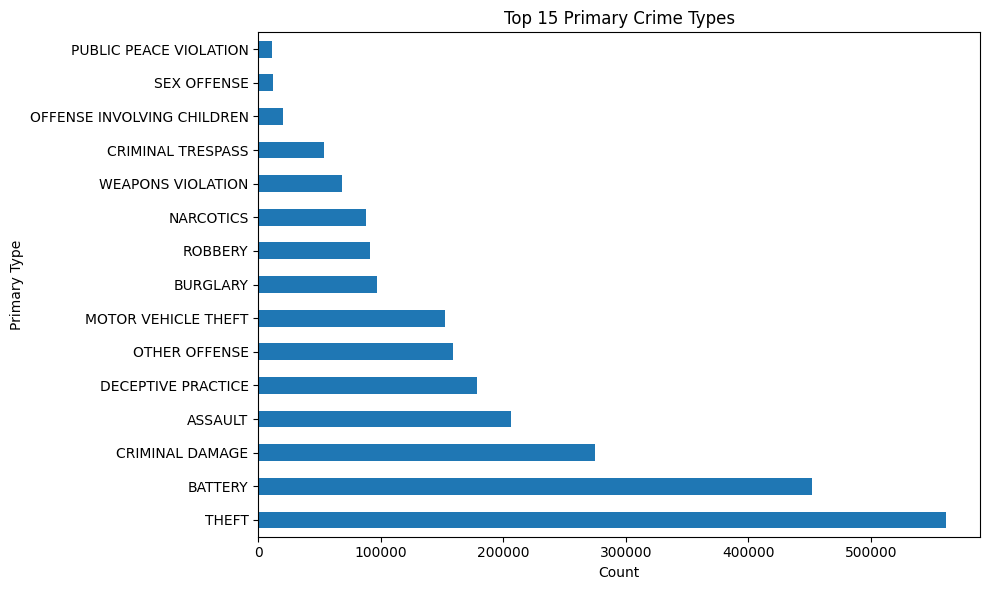

In [7]:
# Visualize primary crime types
import matplotlib.pyplot as plt
primary_counts.head(15).plot(kind='barh', figsize=(10, 6), title='Top 15 Primary Crime Types')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

## 4. Location Description (Where crimes occur)

Understand where crimes typically happen - relevant for location-based predictions.

In [8]:
loc_counts = df['Location Description'].value_counts(dropna=False)
print("Location Description - Top 20:")
print(loc_counts.head(20).to_string())
print("\nTotal unique location types:", df['Location Description'].nunique())

Location Description - Top 20:
Location Description
STREET                                    615198
APARTMENT                                 410983
RESIDENCE                                 370082
SIDEWALK                                  159959
SMALL RETAIL STORE                         71344
RESTAURANT                                 55717
ALLEY                                      52521
PARKING LOT / GARAGE (NON RESIDENTIAL)     49333
OTHER                                      42960
DEPARTMENT STORE                           42157
VEHICLE NON-COMMERCIAL                     39476
GAS STATION                                32733
PARKING LOT/GARAGE(NON.RESID.)             30613
GROCERY FOOD STORE                         27845
COMMERCIAL / BUSINESS OFFICE               26113
OTHER (SPECIFY)                            25229
RESIDENTIAL YARD (FRONT/BACK)              20360
RESIDENCE - PORCH / HALLWAY                19153
RESIDENCE PORCH/HALLWAY                    18521
CONVENIENCE STORE

## 5. Geographic Columns (for Hotspot Analysis)

**Beat** is the primary unit for police deployment – patrol areas where officers are assigned. Use Beat (not District) for location predictions. District, Ward, Community Area provide coarser geography. Lat/Lon enable spatial binning.

In [9]:
print("District - unique count:", df['District'].nunique(), "| Sample:", sorted(df['District'].unique())[:10])
print("Ward - unique count:", df['Ward'].nunique(), "| Range:", df['Ward'].min(), "-", df['Ward'].max())
print("Community Area - unique count:", df['Community Area'].nunique(), "| Missing:", df['Community Area'].isnull().sum())
print("Beat - unique count:", df['Beat'].nunique())
print("\nLatitude/Longitude coverage:", df['Latitude'].notna().sum(), "/", len(df))

District - unique count: 23 | Sample: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(10.0)]
Ward - unique count: 50 | Range: 1.0 - 50.0
Community Area - unique count: 77 | Missing: 203
Beat - unique count: 275

Latitude/Longitude coverage: 2441510 / 2477115


## 6. Date/Time Column Analysis

The Date column is critical - we'll extract year, month, day of week, hour, and other temporal features.

In [10]:
# Parse Date to verify we can extract temporal features
df_temp = df.copy()
df_temp['Date_parsed'] = pd.to_datetime(df_temp['Date'], format='%m/%d/%Y %I:%M:%S %p', errors='coerce')
print("Sample parsed dates:")
print(df_temp[['Date', 'Date_parsed']].dropna().head())
print("\nParse errors (null):", df_temp['Date_parsed'].isnull().sum())

Sample parsed dates:
                     Date Date_parsed
0  03/13/2026 12:00:00 AM  2026-03-13
1  03/13/2026 12:00:00 AM  2026-03-13
2  03/13/2026 12:00:00 AM  2026-03-13
3  03/13/2026 12:00:00 AM  2026-03-13
4  03/13/2026 12:00:00 AM  2026-03-13

Parse errors (null): 0


## 7. Categorical and Binary Columns

Arrest, Domestic, FBI Code - useful for modeling and EDA.

In [11]:
print("Arrest distribution:", df['Arrest'].value_counts())
print("\nDomestic distribution:", df['Domestic'].value_counts())
print("\nFBI Code - top 10:", df['FBI Code'].value_counts().head(10).to_string())

Arrest distribution: Arrest
False    2071690
True      405425
Name: count, dtype: int64

Domestic distribution: Domestic
False    1996332
True      480783
Name: count, dtype: int64

FBI Code - top 10: FBI Code
06     566282
08B    378857
14     274747
26     180327
08A    179497
11     162254
07     152761
05      91261
03      90821
18      88118


## 8. Duplicate and Redundant Columns

Identify columns that may be redundant (e.g., Location vs Lat/Lon, Year in Date).

In [12]:
# Location is (Latitude, Longitude) - redundant
print("Location sample:", df['Location'].iloc[0])
print("Latitude, Longitude:", df['Latitude'].iloc[0], df['Longitude'].iloc[0])
print("\nDuplicate rows (by ID):", df.duplicated(subset=['ID']).sum())
print("Duplicate Case Numbers:", df['Case Number'].duplicated().sum())

Location sample: (41.758395718, -87.562722643)
Latitude, Longitude: 41.758395718 -87.562722643

Duplicate rows (by ID): 0
Duplicate Case Numbers: 311


## 9. Column Retention & Addition Recommendations

**Columns to KEEP:**
- **ID** – Unique identifier (useful for tracking)
- **Date** – Source for temporal features
- **Block** – Street-level location context
- **Primary Type** – Main crime type (key target for prediction)
- **Location Description** – Where crime occurred
- **Arrest, Domestic** – Binary outcomes/features
- **Beat** – Primary unit for police deployment (preferred over District for location prediction)
- **District, Ward, Community Area** – Geographic hierarchy, coarser than Beat
- **Latitude, Longitude** – For mapping and spatial modeling
- **Year** – Already extracted (or derive from Date)
- **IUCR, Description, FBI Code** – Optional for richer crime categorization

**Columns to DROP:**
- **Case Number** – Administrative; ID is sufficient
- **Location** – Redundant with Latitude/Longitude
- **X Coordinate, Y Coordinate** – State plane coordinates; Lat/Lon preferred for mapping
- **Updated On** – Metadata, not predictive

**Columns to ADD (from Date):**
- **Month** (1–12)
- **DayOfWeek** (0–6 or name)
- **Hour** (0–23)
- **Quarter** (1–4)
- **WeekOfYear** (optional)
- **IsWeekend** (boolean)

**Columns to ADD (for modeling):**
- **Lat_bin, Lon_bin** – Spatial grid (0.02 deg) for Beat prediction
- **HourBin** – 6 time-of-day bins
- **Crime_Category** – 5 groups (Violent, Theft, Property, Narcotics, Other)

**Aggregation for modeling:** Aggregate by (Beat, WeekOfYear, DayOfWeek, HourBin) to predict crime levels per bin.

In [13]:
# Summary of recommended columns and additions
recommendations = """
FINAL COLUMN DECISIONS:
======================
KEEP: ID, Date, Block, IUCR, Primary Type, Description, Location Description,
      Arrest, Domestic, Beat, District, Ward, Community Area, FBI Code,
      Latitude, Longitude, Year

DROP: Case Number, Location, X Coordinate, Y Coordinate, Updated On

ADD (from Date): Month, DayOfWeek, Hour, Quarter, WeekOfYear, IsWeekend
"""
print(recommendations)


FINAL COLUMN DECISIONS:
KEEP: ID, Date, Block, IUCR, Primary Type, Description, Location Description,
      Arrest, Domestic, Beat, District, Ward, Community Area, FBI Code,
      Latitude, Longitude, Year

DROP: Case Number, Location, X Coordinate, Y Coordinate, Updated On

ADD (from Date): Month, DayOfWeek, Hour, Quarter, WeekOfYear, IsWeekend

